# <h1 style="text-align: center;">Question 2: How many patients arrive with impaired consciousness, and how dangerous is it?</h1>

This notebook answers Question 2 using two tables produced by our cleaning notebook
**`Team05_PyCraft_1_Cleaning.ipynb`**: `cleaned/responsivenes_cleaned.csv` (consciousness level,
from the Glasgow Coma Scale assessment) joined with `cleaned/hospitalization_discharge_cleaned.csv`
(mortality and outcome data), so we can measure both the **prevalence** of impaired consciousness
and its **danger** in terms of real patient outcomes.

Team05 renamed the hospitalization columns, so this notebook uses the Team05 names:

| Original column | Team05 cleaned column |
|---|---|
| `inpatient_number` | `patient_id` |
| `death_within_28_days` / `_3_months` / `_6_months` | `death_28d` / `death_3m` / `death_6m` |
| `outcome_during_hospitalization` | `hospitalization_outcome` |
| `dischargeday` | `discharge_day` |

`consciousness` has four levels, from least to most severe:
`Clear` (normal) → `ResponsiveToSound` → `ResponsiveToPain` →
`Nonresponsive` (most severe / comatose). We treat any level other than
`Clear` as **"impaired consciousness."** Step 9 cross-checks this label against the numeric
GCS score, which Team05 verified.

**Run order:** run `Team05_PyCraft_1_Cleaning.ipynb` first, then this notebook.

## Step 1 — Load the two tables cleaned by Team05

We read the cleaned files written by the final cell of the Team05 notebook instead of the raw CSVs,
so this analysis uses the same cleaned data as the rest of the project (renamed columns, stripped
`consciousness` text, GCS values checked against their clinical ranges and formula).

In [1]:
from pathlib import Path
import pandas as pd

# Team05_PyCraft_1_Cleaning.ipynb is run from inside the project folder, and its final cell
# saves every cleaned table to <project>/cleaned/<table>_cleaned.csv.
# We look for that folder whether this notebook is opened inside the project folder or one level
# above it. (This replaces os.chdir(...), which fails when the cell is run a second time.)
CANDIDATES = [Path("."), Path("Python_Hackathon_SEP_2026")]
PROJECT = next((p for p in CANDIDATES if (p / "cleaned" / "demography_cleaned.csv").exists()), None)
if PROJECT is None:
    raise FileNotFoundError(
        "Team05 cleaned files not found. Run Team05_PyCraft_1_Cleaning.ipynb first: "
        "its last cell writes the cleaned tables to the 'cleaned' folder.")
CLEANED = PROJECT / "cleaned"
print("Using Team05 cleaned files from:", CLEANED.as_posix())

def load_cleaned(file_name):
    """Read one Team05 output file and give patient_id the same string format Team05 applies
    to demography (so every table merges on identical keys)."""
    d = pd.read_csv(CLEANED / file_name)
    d["patient_id"] = d["patient_id"].astype(str).str.replace(r"\.0$", "", regex=True)
    return d

resp = load_cleaned("responsivenes_cleaned.csv")
hosp = load_cleaned("hospitalization_discharge_cleaned.csv")

# Confirm the Team05 cleaning steps this analysis relies on are present in the files
assert {"death_28d", "death_3m", "death_6m", "hospitalization_outcome", "discharge_day"} <= set(hosp.columns), \
    "expected Team05 hospitalization column names"
assert (resp["gcs"] == resp["eye_opening"] + resp["verbal_response"] + resp["movement"]).all(), \
    "Team05 verified gcs = eye_opening + verbal_response + movement"
assert resp["patient_id"].is_unique and hosp["patient_id"].is_unique

# CSV files do not store dtypes, so re-apply Team05's category dtype for consciousness
resp["consciousness"] = resp["consciousness"].astype("category")

print("responsivenes_cleaned:", resp.shape)
print("hospitalization_discharge_cleaned:", hosp.shape)
print("Missing consciousness values:", resp["consciousness"].isna().sum())

Using Team05 cleaned files from: Python_Hackathon_SEP_2026/cleaned
responsivenes_cleaned: (2008, 6)
hospitalization_discharge_cleaned: (2008, 21)
Missing consciousness values: 0


## Step 2 — How many patients arrive with impaired consciousness?

We create a simple binary flag, `impaired`, for anything other than
`Clear`, then report both the overall count/percentage and the
breakdown across the three impaired severity levels.

In [2]:
resp["impaired"] = resp["consciousness"] != "Clear"

counts = resp["consciousness"].value_counts().reindex(
    ["Clear", "ResponsiveToSound", "ResponsiveToPain", "Nonresponsive"]
)
pct = (counts / len(resp) * 100).round(2)

print("=== Consciousness level at admission ===")
summary = pd.DataFrame({"count": counts, "percent": pct})
print(summary)

n_impaired = resp["impaired"].sum()
pct_impaired = n_impaired / len(resp) * 100
print(f"\nTotal impaired consciousness: {n_impaired} of {len(resp)} patients ({pct_impaired:.2f}%)")

=== Consciousness level at admission ===
                   count  percent
consciousness                    
Clear               1974    98.31
ResponsiveToSound     19     0.95
ResponsiveToPain       4     0.20
Nonresponsive         11     0.55

Total impaired consciousness: 34 of 2008 patients (1.69%)


## Step 3 — Merge with hospitalization/discharge outcomes

To assess "how dangerous" impaired consciousness is, we need real
outcomes: in-hospital outcome (`hospitalization_outcome`), 28-day/3-month/6-month mortality
(`death_28d`, `death_3m`, `death_6m`), and length of stay (`discharge_day`).

In [3]:
outcome_cols = ["patient_id", "hospitalization_outcome",
                "death_28d", "death_3m", "death_6m",
                "discharge_day", "admission_ward"]

merged = resp[["patient_id", "consciousness", "impaired"]].merge(
    hosp[outcome_cols], on="patient_id", how="inner", validate="one_to_one"
)
print("Merged table:", merged.shape)
merged.head()

Merged table: (2008, 9)


,patient_id,consciousness,impaired,hospitalization_outcome,death_28d,death_3m,death_6m,discharge_day,admission_ward
0,857781,Clear,False,Alive,0,0,0,11,Cardiology
1,743087,Clear,False,Alive,0,0,0,8,Cardiology
2,866418,Clear,False,Alive,0,0,0,5,Cardiology
3,775928,Clear,False,Alive,0,0,0,11,Cardiology
4,810128,Clear,False,Alive,0,0,0,5,Cardiology


## Step 4 — Mortality rate: impaired vs. clear consciousness

We compare the 28-day, 3-month, and 6-month death rates between the two
groups. This is the core of "how dangerous" — a much higher mortality
rate in the impaired group demonstrates the clinical danger directly in
terms of patient outcomes, not just severity labels.

In [4]:
mortality_cols = ["death_28d", "death_3m", "death_6m"]

mortality_by_group = merged.groupby("impaired")[mortality_cols].mean() * 100
mortality_by_group.index = mortality_by_group.index.map({False: "Clear", True: "Impaired"})

print("=== Mortality rate (%) by consciousness group ===")
print(mortality_by_group.round(2))

=== Mortality rate (%) by consciousness group ===
          death_28d  death_3m  death_6m
impaired                               
Clear          1.17      1.37      2.13
Impaired      41.18     44.12     44.12


## Step 5 — Relative risk: how many times more dangerous?

Relative risk (RR) compares the probability of an outcome (death) between
the impaired group and the clear group. An RR of, say, 5 means patients
with impaired consciousness are 5 times as likely to die within that
window as patients with clear consciousness.

In [5]:
for col in mortality_cols:
    risk_impaired = merged.loc[merged["impaired"], col].mean()
    risk_clear = merged.loc[~merged["impaired"], col].mean()
    rr = risk_impaired / risk_clear if risk_clear > 0 else float("inf")
    print(f"{col}: risk (impaired) = {risk_impaired*100:.2f}%, "
          f"risk (clear) = {risk_clear*100:.2f}%, relative risk = {rr:.2f}x")

death_28d: risk (impaired) = 41.18%, risk (clear) = 1.17%, relative risk = 35.34x
death_3m: risk (impaired) = 44.12%, risk (clear) = 1.37%, relative risk = 32.25x
death_6m: risk (impaired) = 44.12%, risk (clear) = 2.13%, relative risk = 20.74x


## Step 6 — Is the difference statistically significant?

A chi-square test of independence tells us whether the association between
impaired consciousness and 28-day mortality (the most immediate, clinically
important outcome) is statistically significant, or could plausibly be
due to chance given the small number of impaired patients.

In [6]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(merged["impaired"], merged["death_28d"])
print("Contingency table (impaired consciousness vs. death within 28 days):")
print(ct)

chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nchi2 = {chi2:.3f}, degrees of freedom = {dof}, p-value = {p:.6f}")
print("Significant association (p<0.05)?", p < 0.05)

Contingency table (impaired consciousness vs. death within 28 days):
death_28d     0   1
impaired           
False      1951  23
True         20  14

chi2 = 274.139, degrees of freedom = 1, p-value = 0.000000
Significant association (p<0.05)? True


## Step 7 — Discharge outcome and length of stay by group

Beyond death flags, we also look at the overall
`hospitalization_outcome` category and average length of stay
(`discharge_day`), which round out the picture of how much more serious
a hospitalization becomes once consciousness is impaired.

In [7]:
outcome_ct = pd.crosstab(merged["impaired"], merged["hospitalization_outcome"], normalize="index") * 100
outcome_ct.index = outcome_ct.index.map({False: "Clear", True: "Impaired"})
print("=== Discharge outcome (%) by consciousness group ===")
print(outcome_ct.round(1))

los_by_group = merged.groupby("impaired")["discharge_day"].agg(["mean", "median"])
los_by_group.index = los_by_group.index.map({False: "Clear", True: "Impaired"})
print("\n=== Length of stay (days) by consciousness group ===")
print(los_by_group.round(1))

=== Discharge outcome (%) by consciousness group ===
hospitalization_outcome  Alive  Dead  DischargeAgainstOrder
impaired                                                   
Clear                     94.9   0.3                    4.8
Impaired                  47.1  17.6                   35.3

=== Length of stay (days) by consciousness group ===
          mean  median
impaired              
Clear      9.4     8.0
Impaired   9.0     7.0


## Step 8 — Visualize the mortality gradient across all 4 consciousness levels

Rather than only comparing the binary impaired/clear split, this chart
shows the mortality rate rising across the full severity gradient —
`Clear` → `ResponsiveToSound` → `ResponsiveToPain` → `Nonresponsive` —
which best illustrates the danger scaling with severity.

consciousness
Clear                 1.17
ResponsiveToSound    15.79
ResponsiveToPain     25.00
Nonresponsive        90.91
Name: death_28d, dtype: float64


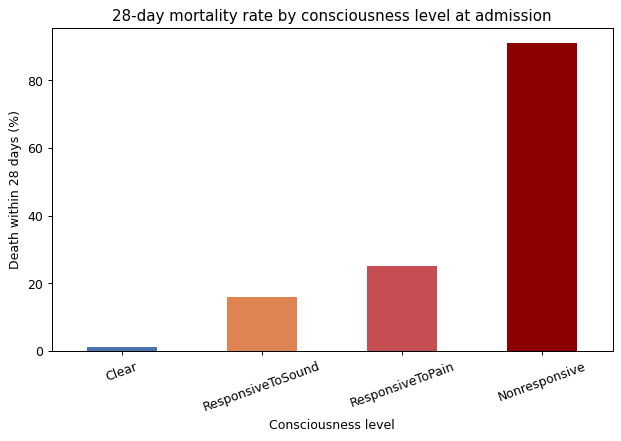

In [8]:
import matplotlib.pyplot as plt

full = resp[["patient_id", "consciousness"]].merge(hosp[outcome_cols], on="patient_id", how="inner", validate="one_to_one")
mortality_by_level = (full.groupby("consciousness", observed=True)["death_28d"].mean() * 100) \
    .reindex(["Clear", "ResponsiveToSound", "ResponsiveToPain", "Nonresponsive"])

fig, ax = plt.subplots(figsize=(7, 5))
mortality_by_level.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#C44E52", "#8C0000"])
ax.set_title("28-day mortality rate by consciousness level at admission")
ax.set_xlabel("Consciousness level")
ax.set_ylabel("Death within 28 days (%)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print(mortality_by_level.round(2))

## Step 9 — Cross-check the consciousness label against the GCS score

Team05's cleaning notebook verified that `gcs` always equals `eye_opening + verbal_response + movement`
and stays within the clinical range 3–15. A GCS below 15 means consciousness is reduced, so we can
use the score to check whether the text label (`consciousness`) catches every impaired patient.
If some patients are labelled `Clear` while their GCS is below 15, then the label-based count in
Step 2 is a **lower bound** on how many patients arrive with impaired consciousness.

In [9]:
gcs_check = resp[["patient_id", "consciousness", "gcs"]].merge(
    hosp[["patient_id", "death_28d"]], on="patient_id", how="inner", validate="one_to_one"
)
gcs_check["impaired_label"] = gcs_check["consciousness"] != "Clear"
gcs_check["impaired_gcs"] = gcs_check["gcs"] < 15

agreement = pd.crosstab(gcs_check["impaired_label"], gcs_check["impaired_gcs"],
                        rownames=["label says impaired"], colnames=["GCS < 15"])
print("=== Label vs GCS ===")
print(agreement)

hidden = gcs_check[~gcs_check["impaired_label"] & gcs_check["impaired_gcs"]]
print(f"\nImpaired by label: {gcs_check['impaired_label'].sum()} | "
      f"impaired by GCS < 15: {gcs_check['impaired_gcs'].sum()} | "
      f"labelled 'Clear' but GCS < 15: {len(hidden)} (of whom GCS <= 8: {(hidden['gcs'] <= 8).sum()})")

gcs_mortality = gcs_check.groupby("impaired_gcs")["death_28d"].agg(patients="size", deaths="sum")
gcs_mortality["death_28d_%"] = (gcs_mortality["deaths"] / gcs_mortality["patients"] * 100).round(2)
gcs_mortality.index = gcs_mortality.index.map({False: "GCS 15", True: "GCS < 15"})
rr_gcs = gcs_mortality.loc["GCS < 15", "death_28d_%"] / gcs_mortality.loc["GCS 15", "death_28d_%"]
print("\n=== 28-day mortality using the GCS definition ===")
print(gcs_mortality)
print(f"Relative risk (GCS < 15 vs GCS 15): {rr_gcs:.2f}x")

=== Label vs GCS ===
GCS < 15             False  True 
label says impaired              
False                 1951     23
True                     0     34

Impaired by label: 34 | impaired by GCS < 15: 57 | labelled 'Clear' but GCS < 15: 23 (of whom GCS <= 8: 3)

=== 28-day mortality using the GCS definition ===
              patients  deaths  death_28d_%
impaired_gcs                               
GCS 15            1951      22         1.13
GCS < 15            57      15        26.32
Relative risk (GCS < 15 vs GCS 15): 23.29x


## Step 10 — Save the summary tables

In [10]:
output_folder = CLEANED   # the same 'cleaned' folder the Team05 notebook writes to

summary.to_csv(output_folder / "q2_consciousness_prevalence.csv")
mortality_by_group.round(2).to_csv(output_folder / "q2_mortality_by_group.csv")
outcome_ct.round(2).to_csv(output_folder / "q2_discharge_outcome_by_group.csv")
mortality_by_level.round(2).to_csv(output_folder / "q2_mortality_by_consciousness_level.csv")
agreement.to_csv(output_folder / "q2_label_vs_gcs_agreement.csv")
gcs_mortality.to_csv(output_folder / "q2_mortality_by_gcs_group.csv")

print("Saved summary tables to:", output_folder.as_posix())

Saved summary tables to: Python_Hackathon_SEP_2026/cleaned


## Summary

- **Data source:** all results use the tables cleaned by `Team05_PyCraft_1_Cleaning.ipynb`
  (`responsivenes_cleaned.csv`, `hospitalization_discharge_cleaned.csv`), so they match the rest
  of the project.
- **Prevalence:** the count/percentage table in Step 2 gives the exact
  number and share of patients arriving with any degree of impaired
  consciousness according to the `consciousness` label, plus the breakdown across the 3 impaired
  severity levels. Step 9 shows the label misses some patients whose GCS is below 15, so the
  GCS-based count is the more complete answer.
- **Danger:** Steps 4-6 show the actual mortality rate difference, the
  relative risk multiplier, and whether that difference is statistically
  significant — this is the direct evidence for "how dangerous" impaired
  consciousness is, rather than just a severity label. Step 8's chart
  shows that danger scales with how impaired the patient is, not just a
  flat impaired-vs-clear split. Step 9 repeats the mortality comparison with the GCS definition.